In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

/var/folders/rc/f9hr8q4x1wsg0lzbhtqkgr_m0000gn/T/ipykernel_14594/783822422.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
#this example shows how to generate the plots for the entire CDD dataset
#the code marked with "CHANGE" needs to be updated when using a different data file
data = pd.read_csv("all_exampes_dataframe_CDD.csv") #CHNAGE: can use path to any of the 4 csv files provided


data = data.dropna()
df_C = data[data["Domain"].str.lower().str.startswith("c")]
df_B = data[~data["Domain"].str.lower().str.startswith("c")]

print("B domains:", df_B.shape) #0 examples, since we are using a datafile only with CDD examples
print("C domains:", df_C.shape)


data = df_C #CHANGE: to df_B if using  all_exampes_dataframe_BB.csv, or OVER_05_all_exampes_dataframe_BB.csv

#formatting
data = data.rename(columns={"ankh_DD": 'Ankh_D', "us_DD": 'US_D', "B45_DD" : "B45_D", "B50_DD" : "B50_D", "B62_DD" : "B62_D", "B80_DD" : "B80_D", "B90_DD" : "B90_D"})
data = data.rename(columns={"us_POS" : "US_POS", "us_CC" : "US_CC", "us_IA" : "US_IA" })
data = data.rename(columns={"ankh_POS" : "Ankh_POS", "ankh_CC" : "Ankh_CC", "ankh_IA" : "Ankh_IA" })

B domains: (0, 48)
C domains: (10376, 48)


In [3]:
#sliding window smoothing function
def sliding_window_mean(x, y, window_size, step):

    #the x and y points in 2 lists 
    x = np.array(x)
    y = np.array(y)

    #sort by x just to be safe
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    x_smooth = []
    y_smooth = []

    min_x = x.min()
    max_x = x.max()
    start = min_x

    while start + window_size <= max_x:
        end = start + window_size
        mask = (x >= start) & (x < end)
        if mask.sum() > 0:
            x_smooth.append(x[mask].mean())
            y_smooth.append(y[mask].mean())
        start += step

    return np.array(x_smooth), np.array(y_smooth)

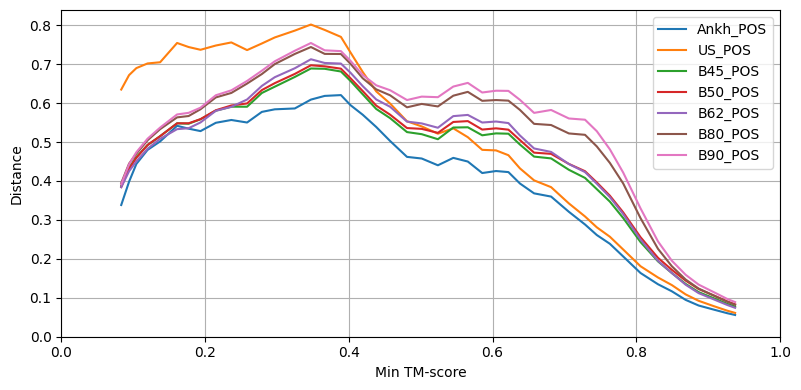

In [4]:
#min tm score plots

#reset
data = df_C #CHANGE: to df_B if using the BB data
data = data.rename(columns={"ankh_DD": 'Ankh_D', "us_DD": 'US_D', "B45_DD" : "B45_D", "B50_DD" : "B50_D", "B62_DD" : "B62_D", "B80_DD" : "B80_D", "B90_DD" : "B90_D"})
data = data.rename(columns={"us_POS" : "US_POS", "us_CC" : "US_CC", "us_IA" : "US_IA" })
data = data.rename(columns={"ankh_POS" : "Ankh_POS", "ankh_CC" : "Ankh_CC", "ankh_IA" : "Ankh_IA" })


data["min_TM_score"] = data[["TM-score1", "TM-score2"]].min(axis=1)
x = data["min_TM_score"]


#this example generated the POS plot. for the other plots, selectively uncomment 1 "y_columns" list
#for example, if you want the IA plot, comment the POS list, and uncomment the IA list

####################
#only uncomment one y_columns list at a time
####################

y_columns = ["Ankh_POS", "US_POS", "B45_POS", "B50_POS", "B62_POS", "B80_POS", "B90_POS"]
# y_columns = ["Ankh_D", "US_D", "B45_D", "B50_D", "B62_D", "B80_D", "B90_D"]
# y_columns = ["Ankh_CC", "US_CC", "B45_CC", "B50_CC", "B62_CC", "B80_CC", "B90_CC"]
# y_columns = ["Ankh_IA", "US_IA", "B45_IA", "B50_IA", "B62_IA", "B80_IA", "B90_IA"]

####################


#choose window settings
window_size = 0.1 #10 for identity and .1 for min TM-score
step = 0.02 #2 for identity and .02 or .05 for min TM-score

#generating the plot
plt.figure(figsize=(8, 4))

#plot each line
for metric in y_columns:
    x_vals, y_vals = sliding_window_mean(x, data[metric], window_size, step)
    plt.plot(x_vals, y_vals, label=metric)

#formatting
plt.xlabel("Min TM-score")
plt.ylabel("Distance")

plt.legend()
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()


plt.xlim(0,1) #or plt.xlim(0.5,1)
plt.ylim(0,)


# plt.savefig("POS_vs_min_tm_score_weighted_avg.png", dpi=300, bbox_inches='tight') #CHANGE: file name if you want to save plot as png

plt.show()


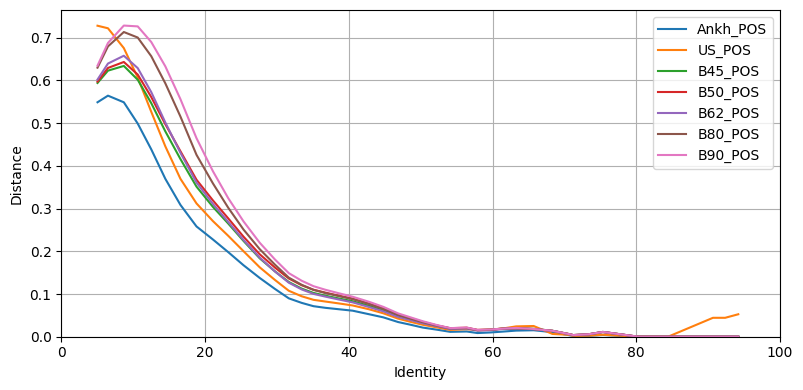

In [5]:
#identity plots

#this example generated the POS plot. for the other plots, selectively uncomment 1 "y_columns" list
#for example, if you want the IA plot, comment the POS list, and uncomment the IA list

####################
#only uncomment one y_columns list at a time
####################

y_columns = ["Ankh_POS", "US_POS", "B45_POS", "B50_POS", "B62_POS", "B80_POS", "B90_POS"]
# y_columns = ["Ankh_D", "US_D", "B45_D", "B50_D", "B62_D", "B80_D", "B90_D"]
# y_columns = ["Ankh_CC", "US_CC", "B45_CC", "B50_CC", "B62_CC", "B80_CC", "B90_CC"]
# y_columns = ["Ankh_IA", "US_IA", "B45_IA", "B50_IA", "B62_IA", "B80_IA", "B90_IA"]

####################

x = data["identity"]

#choose window settings
window_size = 10  #10 for identity and .1 for min TM-score
step = 2 #2 for identity and .02 or .05 for min TM-score


plt.figure(figsize=(8, 4))

#plot each line
for metric in y_columns:
    x_vals, y_vals = sliding_window_mean(x, data[metric], window_size, step)
    plt.plot(x_vals, y_vals, label=metric)


#formatting
plt.xlabel("Identity")
plt.ylabel("Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xlim(0,100)
plt.ylim(0,)

# plt.savefig("POS_identity_weighted_avg.png", dpi=300, bbox_inches='tight')  #CHANGE: file name if you want to save plot as png

plt.show()


## Add ZOOM IN window to the above plot

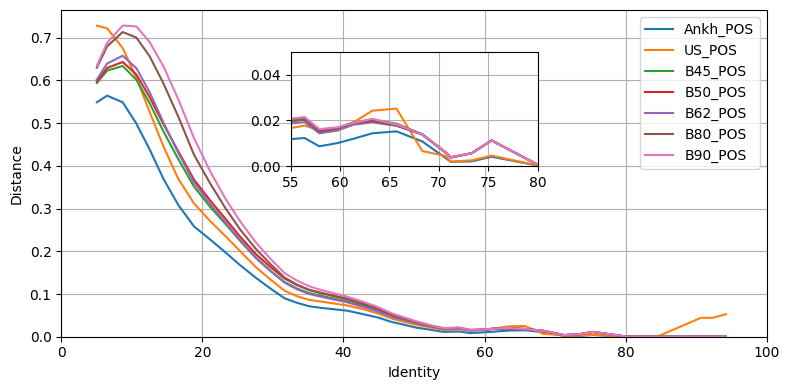

In [6]:
#make sure to run the above identity plot cell before running this one

x = data["identity"]

#plot setup
fig, ax = plt.subplots(figsize=(8, 4))
#choose window settings for identity
window_size = 10  
step = 2          

#plot each metric line
for metric in y_columns:
    x_vals, y_vals = sliding_window_mean(x, data[metric], window_size, step)
    ax.plot(x_vals, y_vals, label=metric)

#formatting for main plot
ax.set_xlabel("Identity")
ax.set_ylabel("Distance")
ax.set_xlim(0, 100)
ax.set_ylim(0, )
ax.grid(True)
ax.legend(loc="upper right")
fig.tight_layout()


#define zoom region — customize as needed
x1, x2 = 55, 80   #zoom in on 55–80% identity
y1, y2 = 0, 0.05  #adjust based on your data range

#add inset without zoom lines
axins = inset_axes(ax, width="35%", height="35%", loc='upper center', borderpad=3)

#plot again in inset
for metric in y_columns:
    x_vals, y_vals = sliding_window_mean(x, data[metric], window_size, step)
    axins.plot(x_vals, y_vals)

#set zoom region
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(True)

#save and show
# plt.savefig("POS_identity_weighted_avg_with_zoom.png", dpi=300, bbox_inches='tight')  #CHANGE: file name if you want to save plot as png
plt.show()
